# Retail Sales Analysis - Exploratory Data Analysis

**Goal:** understand what drives sales and profit for a US retail business (2024-2025) and turn the findings into actions.

**Business questions**
1. How are sales and profit trending over time? Is the business growing?
2. Which regions, categories and products drive revenue - and which lose money?
3. How does discounting affect profitability?
4. Who are the most valuable customers / segments?
5. Is shipping performance consistent with the promised service level?

**Data:** `data/cleaned/retail_sales_clean.csv` - 6,000 orders, cleaned in `scripts/02_clean_data.py`
(see `data/cleaned/data_quality_report.md` for the cleaning log).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
IMG = ROOT / "images"
IMG.mkdir(exist_ok=True)

# ---- chart style: thin marks, recessive grid, fixed categorical palette ----
PALETTE = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
           "yellow": "#eda100", "red": "#e34948", "gray": "#9a9892"}
CAT_COLORS = {"Technology": PALETTE["blue"], "Furniture": PALETTE["orange"], "Office Supplies": PALETTE["aqua"]}
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10,
})
money = mtick.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K")

def save(name):
    plt.tight_layout()
    plt.savefig(IMG / name, bbox_inches="tight")
    plt.show()

df = pd.read_csv(ROOT / "data" / "cleaned" / "retail_sales_clean.csv", parse_dates=["order_date", "ship_date"])
print(df.shape)
df.head()

(6000, 27)


,order_id,order_date,ship_date,ship_days,ship_mode,year,quarter,month,month_name,year_month,...,sub_category,product_name,quantity,unit_price,discount,sales,profit,profit_margin,is_profitable,payment_method
0,ORD-2024-00884,2024-01-01,2024-01-06,5,Second Class,2024,Q1,1,Jan,2024-01,...,Accessories,USB-C Hub,4,138.64,0.1,499.10,108.12,0.2166,True,Cash on Delivery
1,ORD-2024-05696,2024-01-01,2024-01-04,3,First Class,2024,Q1,1,Jan,2024-01,...,Accessories,Wireless Mouse,5,82.24,0.0,411.20,133.25,0.3241,True,PayPal
2,ORD-2024-05595,2024-01-01,2024-01-04,3,First Class,2024,Q1,1,Jan,2024-01,...,Phones,Smartphone X,6,321.78,0.3,1351.48,-97.16,-0.0719,False,PayPal
3,ORD-2024-04375,2024-01-01,2024-01-01,0,Same Day,2024,Q1,1,Jan,2024-01,...,Art,Marker Set,4,12.24,0.2,39.17,5.38,0.1374,True,PayPal
4,ORD-2024-01876,2024-01-01,2024-01-05,4,Second Class,2024,Q1,1,Jan,2024-01,...,Binders,3-Ring Binder,1,23.32,0.0,23.32,4.58,0.1964,True,Cash on Delivery


## 1. Dataset overview
First look at structure, types, and summary statistics. Nulls should be zero because cleaning already ran.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        6000 non-null   str           
 1   order_date      6000 non-null   datetime64[us]
 2   ship_date       6000 non-null   datetime64[us]
 3   ship_days       6000 non-null   int64         
 4   ship_mode       6000 non-null   str           
 5   year            6000 non-null   int64         
 6   quarter         6000 non-null   str           
 7   month           6000 non-null   int64         
 8   month_name      6000 non-null   str           
 9   year_month      6000 non-null   str           
 10  customer_id     6000 non-null   str           
 11  customer_name   6000 non-null   str           
 12  segment         6000 non-null   str           
 13  region          6000 non-null   str           
 14  state           6000 non-null   str           
 15  city           

In [3]:
df[["quantity", "unit_price", "discount", "sales", "profit", "profit_margin", "ship_days"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
quantity,6000.0,3.51,1.58,1.00,2.00,3.00,4.00,10.00
unit_price,6000.0,214.65,294.35,3.06,20.88,97.36,283.31,1498.53
discount,6000.0,0.11,0.14,0.00,0.00,0.10,0.20,0.50
sales,6000.0,676.50,1069.64,2.21,58.98,235.15,796.78,10444.49
profit,6000.0,59.04,165.94,-960.74,3.73,18.28,66.74,2098.63
profit_margin,6000.0,0.14,0.15,-0.40,0.05,0.15,0.25,0.45
ship_days,6000.0,4.93,1.68,0.00,4.00,5.00,6.00,7.00


In [4]:
kpis = {
    "Total orders": f"{len(df):,}",
    "Unique customers": f"{df.customer_id.nunique():,}",
    "Total sales": f"${df.sales.sum():,.0f}",
    "Total profit": f"${df.profit.sum():,.0f}",
    "Overall margin": f"{df.profit.sum()/df.sales.sum():.1%}",
    "Avg order value": f"${df.sales.mean():,.0f}",
    "Loss-making orders": f"{(~df.is_profitable).mean():.1%}",
}
pd.Series(kpis, name="value").to_frame()

,value
Total orders,"6,000"
Unique customers,800
Total sales,"$4,059,006"
Total profit,"$354,239"
Overall margin,8.7%
Avg order value,$677
Loss-making orders,16.9%


**Observation:** margin is thin (~8.7%) and roughly 1 in 5 orders loses money. Profit has a wide spread (min strongly negative), so we need to find *where* the losses concentrate.

## 2. Sales trend over time
Is the business growing? Compare 2024 and 2025 month by month, plus a 3-month moving average to smooth noise.

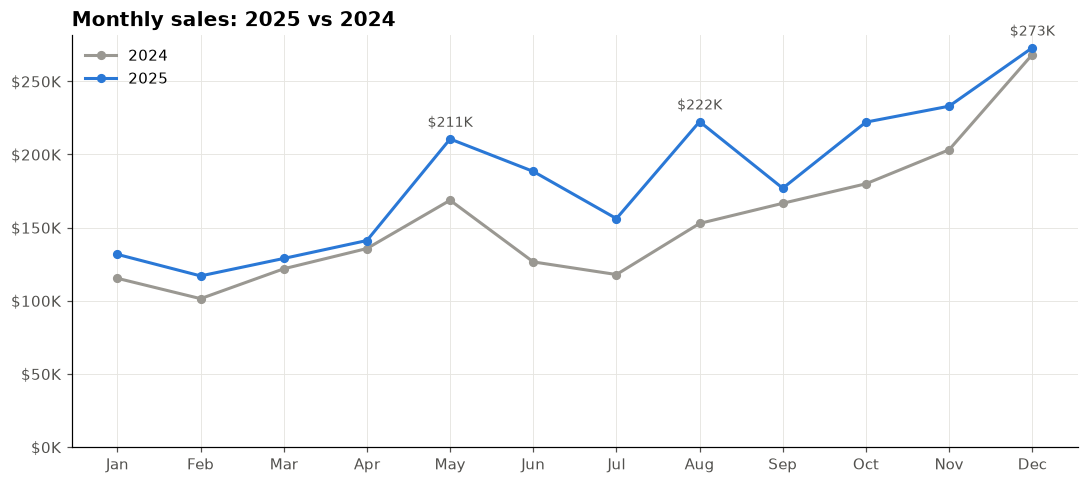

YoY growth % by month:
 month
1     14.2
2     15.3
3      5.8
4      4.0
5     24.8
6     48.9
7     32.4
8     45.5
9      6.2
10    23.4
11    14.7
12     1.7

Total 2024: $1,858,061 | Total 2025: $2,200,945 | Growth: 18.5%


In [5]:
monthly = df.groupby(["year", "month"], as_index=False).agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "count"))
pivot = monthly.pivot(index="month", columns="year", values="sales")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(pivot.index, pivot[2024], color=PALETTE["gray"], lw=2, marker="o", ms=5, label="2024")
ax.plot(pivot.index, pivot[2025], color=PALETTE["blue"], lw=2, marker="o", ms=5, label="2025")
for m, v in pivot[2025].items():
    if m in (5, 8, 12):
        ax.annotate(f"${v/1000:.0f}K", (m, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color="#52514e")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(money); ax.set_ylim(0)
ax.set_title("Monthly sales: 2025 vs 2024"); ax.legend(frameon=False)
save("01_monthly_sales_trend.png")

yoy = ((pivot[2025] - pivot[2024]) / pivot[2024] * 100).round(1)
print("YoY growth % by month:\n", yoy.to_string())
print(f"\nTotal 2024: ${pivot[2024].sum():,.0f} | Total 2025: ${pivot[2025].sum():,.0f} | Growth: {(pivot[2025].sum()/pivot[2024].sum()-1):.1%}")

**Observation:** every month of 2025 beat the same month of 2024 (+18.5% for the year). Strong seasonality: Q4 (Oct-Dec) is the peak, February the trough. Inventory and marketing spend should follow this curve.

## 3. Where does revenue come from? Category and sub-category
Sales tells us *size*; profit tells us *health*. Plot them side by side so a big but unprofitable line stands out.

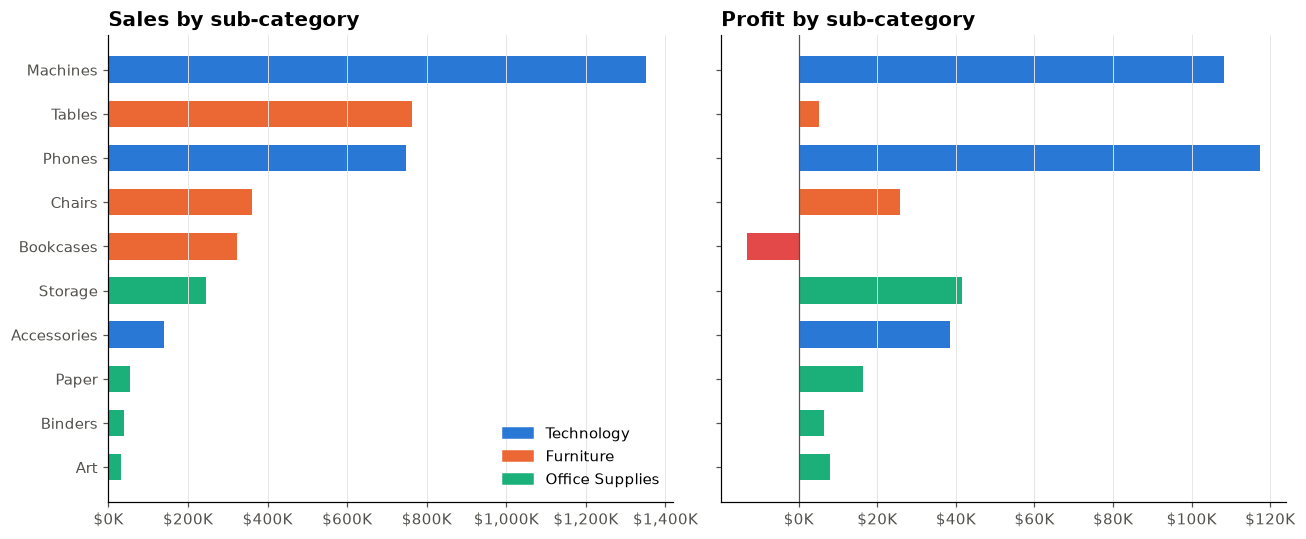

,category,sub_category,sales,profit,margin
0,Technology,Machines,1352090.73,108310.78,8.0
1,Furniture,Tables,763675.67,5047.94,0.7
2,Technology,Phones,747895.19,117504.28,15.7
3,Furniture,Chairs,361009.04,25753.26,7.1
4,Furniture,Bookcases,324073.49,-13190.25,-4.1
5,Office Supplies,Storage,244875.68,41584.15,17.0
6,Technology,Accessories,139218.81,38478.22,27.6
7,Office Supplies,Paper,54174.84,16241.16,30.0
8,Office Supplies,Binders,40082.02,6563.31,16.4
9,Office Supplies,Art,31910.61,7945.79,24.9


In [6]:
sub = (df.groupby(["category", "sub_category"], as_index=False)
         .agg(sales=("sales", "sum"), profit=("profit", "sum"))
         .sort_values("sales"))
sub["margin"] = sub.profit / sub.sales

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = sub.category.map(CAT_COLORS)
axes[0].barh(sub.sub_category, sub.sales, color=colors, height=0.6)
axes[0].xaxis.set_major_formatter(money); axes[0].set_title("Sales by sub-category")
axes[1].barh(sub.sub_category, sub.profit, color=[PALETTE["red"] if p < 0 else c for p, c in zip(sub.profit, colors)], height=0.6)
axes[1].axvline(0, color="#52514e", lw=0.8); axes[1].xaxis.set_major_formatter(money); axes[1].set_title("Profit by sub-category")
for ax in axes: ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in CAT_COLORS.values()]
axes[0].legend(handles, CAT_COLORS.keys(), frameon=False, loc="lower right")
save("02_sales_profit_by_subcategory.png")
sub.sort_values("sales", ascending=False).assign(margin=lambda d: (d.margin*100).round(1)).reset_index(drop=True)

**Observation:** Technology (Machines + Phones) is both the biggest and the most profitable line. Furniture is the problem: **Tables generate 19% of revenue at ~0.7% margin and Bookcases lose money outright**. Office Supplies is small but healthy (~17% margin on Storage/Paper).

## 4. Regional performance

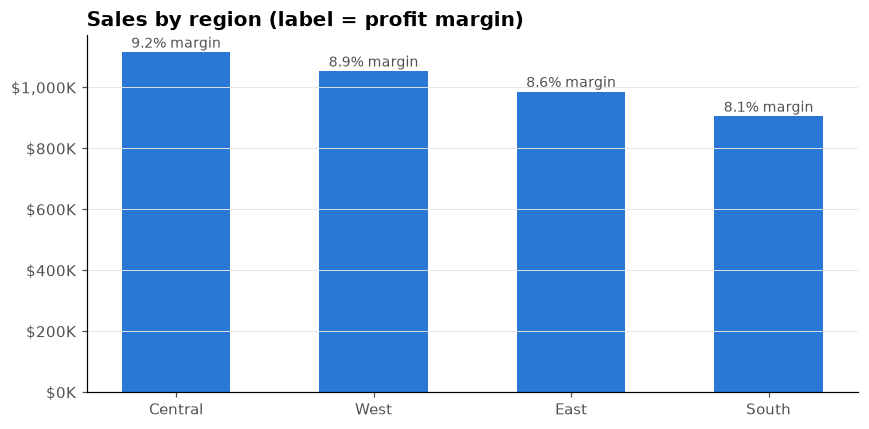

,region,sales,profit,orders,margin
0,Central,1114978.62,102832.92,1625,9.22
1,West,1053046.82,93356.93,1572,8.87
2,East,986148.06,84383.14,1423,8.56
3,South,904832.58,73665.65,1380,8.14


In [7]:
reg = df.groupby("region", as_index=False).agg(sales=("sales","sum"), profit=("profit","sum"), orders=("order_id","count"))
reg["margin"] = (reg.profit/reg.sales*100).round(2)
reg = reg.sort_values("sales", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(reg.region, reg.sales, color=PALETTE["blue"], width=0.55)
for b, m in zip(bars, reg.margin):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15000, f"{m:.1f}% margin", ha="center", fontsize=9, color="#52514e")
ax.yaxis.set_major_formatter(money); ax.grid(axis="x", visible=False); ax.set_title("Sales by region (label = profit margin)")
save("03_sales_by_region.png")
reg.reset_index(drop=True)

**Observation:** Central leads on both sales and margin; South trails on both. The spread is modest (8.1%-9.2%), so region is not the main driver of losses - product mix and discounting are.

## 5. Discount vs profitability
The most actionable question: at what discount level do orders stop making money?

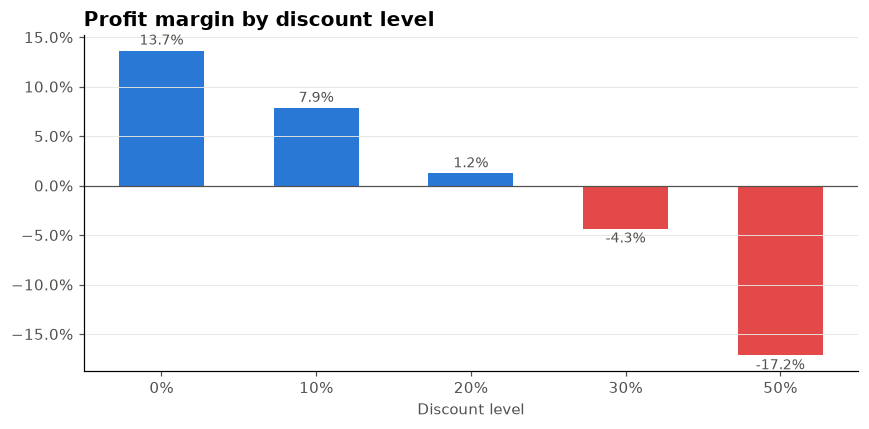

,orders,avg_profit,margin,loss_pct
discount,,,,
0.0,2963,106.89,13.65,5.53
0.1,1185,52.24,7.86,11.81
0.2,900,7.69,1.25,26.22
0.3,641,-19.64,-4.35,35.73
0.5,311,-60.14,-17.16,79.10


In [8]:
disc = df.groupby("discount").agg(orders=("order_id","count"), avg_profit=("profit","mean"),
                                  margin=("profit", lambda s: s.sum()/df.loc[s.index,"sales"].sum()*100),
                                  loss_pct=("is_profitable", lambda s: (~s).mean()*100)).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
cols = [PALETTE["red"] if m < 0 else PALETTE["blue"] for m in disc.margin]
ax.bar([f"{d:.0%}" for d in disc.index], disc.margin, color=cols, width=0.55)
ax.axhline(0, color="#52514e", lw=0.8)
for i, (m, l) in enumerate(zip(disc.margin, disc.loss_pct)):
    ax.text(i, m + (0.6 if m >= 0 else -1.4), f"{m:.1f}%", ha="center", fontsize=9, color="#52514e")
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.grid(axis="x", visible=False)
ax.set_xlabel("Discount level"); ax.set_title("Profit margin by discount level")
save("04_discount_vs_margin.png")
disc

In [9]:
# Statistical check: is profit really different across discount levels? (one-way ANOVA + correlation)
groups = [g.profit.values for _, g in df.groupby("discount")]
f_stat, p_val = stats.f_oneway(*groups)
r, p_r = stats.pearsonr(df.discount, df.profit_margin)
print(f"ANOVA  F = {f_stat:.1f}, p = {p_val:.2e}  -> profit differs significantly across discount levels")
print(f"Pearson r(discount, profit_margin) = {r:.3f}, p = {p_r:.2e}  -> strong negative relationship")

# How much profit would we recover if orders at >=30% discount had been sold at 20%?
hi = df[df.discount >= 0.3]
recovered = (hi.unit_price * hi.quantity * (1 - 0.2) - hi.sales).sum()
print(f"\nOrders at >=30% discount: {len(hi):,} ({len(hi)/len(df):.1%}) with total profit ${hi.profit.sum():,.0f}")
print(f"Capping discount at 20% on those orders would add ~${recovered:,.0f} in revenue (if volume held).")

ANOVA  F = 178.7, p = 7.81e-145  -> profit differs significantly across discount levels
Pearson r(discount, profit_margin) = -0.570, p = 0.00e+00  -> strong negative relationship

Orders at >=30% discount: 952 (15.9%) with total profit $-31,289
Capping discount at 20% on those orders would add ~$106,738 in revenue (if volume held).


**Observation:** margin falls monotonically with discount. At 0-10% the business earns 8-14%; at 20% it barely breaks even; **at 30%+ it loses money on most orders** (36-79% of orders unprofitable). ANOVA confirms the difference is statistically significant (p << 0.001). Recommendation: cap discounts at 20% unless clearing dead stock.

## 6. Profit distribution by category
Box plots show spread and outliers, not just the average.

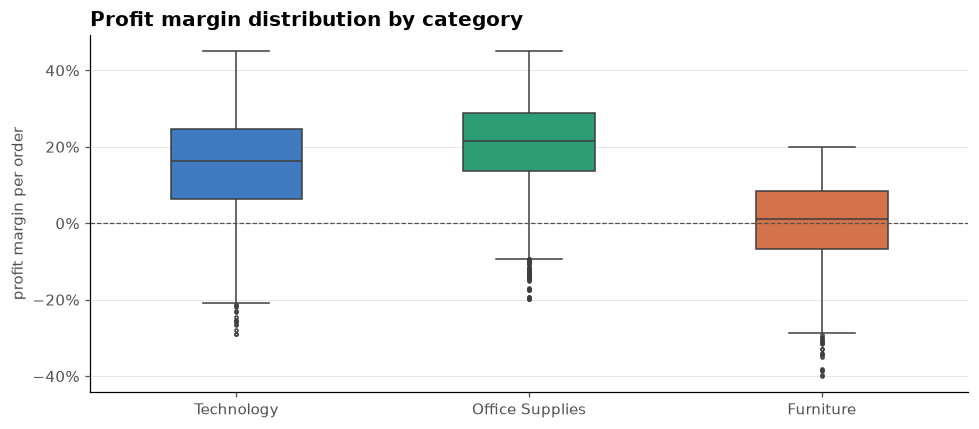

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Furniture,1469.0,-0.001,0.111,-0.399,-0.067,0.010,0.083,0.199
Office Supplies,2980.0,0.208,0.117,-0.200,0.136,0.216,0.289,0.449
Technology,1551.0,0.157,0.133,-0.290,0.062,0.164,0.246,0.449


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
order = ["Technology", "Office Supplies", "Furniture"]
sns.boxplot(data=df, x="category", y="profit_margin", order=order, palette=CAT_COLORS, width=0.45,
            fliersize=2, linewidth=1, ax=ax)
ax.axhline(0, color="#52514e", lw=0.8, ls="--")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.grid(axis="x", visible=False)
ax.set_xlabel(""); ax.set_ylabel("profit margin per order"); ax.set_title("Profit margin distribution by category")
save("05_margin_distribution_by_category.png")
df.groupby("category").profit_margin.describe(percentiles=[.25,.5,.75]).round(3)

## 7. Customers and segments

In [11]:
seg = df.groupby("segment").agg(customers=("customer_id","nunique"), orders=("order_id","count"),
                                sales=("sales","sum"), aov=("sales","mean"), profit=("profit","sum"))
seg["orders_per_customer"] = (seg.orders/seg.customers).round(2)
seg["margin_pct"] = (seg.profit/seg.sales*100).round(2)
seg.round(2)

,customers,orders,sales,aov,profit,orders_per_customer,margin_pct
segment,,,,,,,
Consumer,390,2955,2002531.56,677.68,170367.14,7.58,8.51
Corporate,242,1811,1210676.51,668.51,104288.39,7.48,8.61
Home Office,168,1234,845798.01,685.41,79583.11,7.35,9.41


Top 20% of customers = 41.2% of revenue


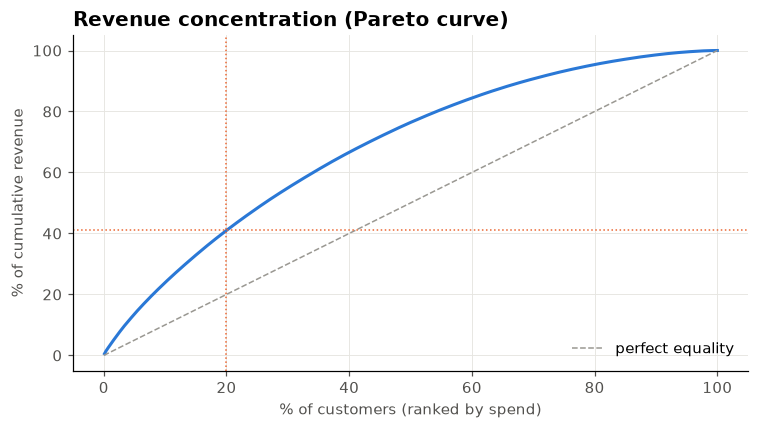

In [12]:
# Customer concentration: what share of revenue comes from the top 20% of customers? (Pareto check)
cust = df.groupby("customer_id").sales.sum().sort_values(ascending=False)
cum = cust.cumsum() / cust.sum()
top20 = cum.iloc[int(len(cust)*0.2)]
print(f"Top 20% of customers = {top20:.1%} of revenue")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum)+1)/len(cum)*100, cum.values*100, color=PALETTE["blue"], lw=2)
ax.plot([0,100],[0,100], color=PALETTE["gray"], lw=1, ls="--", label="perfect equality")
ax.axvline(20, color=PALETTE["orange"], lw=1, ls=":"); ax.axhline(top20*100, color=PALETTE["orange"], lw=1, ls=":")
ax.set_xlabel("% of customers (ranked by spend)"); ax.set_ylabel("% of cumulative revenue")
ax.set_title("Revenue concentration (Pareto curve)"); ax.legend(frameon=False)
save("06_customer_pareto.png")

**Observation:** revenue is fairly evenly spread (top 20% of customers = ~41% of revenue, not the classic 80/20), so there is no dangerous dependence on a few accounts. Segments behave similarly; Home Office has the highest margin and order value, a candidate for targeted upsell.

## 8. Shipping performance

In [13]:
ship = df.groupby("ship_mode").agg(orders=("order_id","count"), avg_days=("ship_days","mean"), max_days=("ship_days","max")).round(2)
ship = ship.reindex(["Same Day", "First Class", "Second Class", "Standard Class"])
sla = {"Same Day": 1, "First Class": 3, "Second Class": 4, "Standard Class": 6}
ship["sla_days"] = ship.index.map(sla)
ship["within_sla_pct"] = [ (df[df.ship_mode==m].ship_days <= sla[m]).mean()*100 for m in ship.index ]
ship.round(1)

,orders,avg_days,max_days,sla_days,within_sla_pct
ship_mode,,,,,
Same Day,298,1.0,2,1,67.8
First Class,856,3.0,4,3,65.9
Second Class,1228,4.0,5,4,66.1
Standard Class,3618,6.0,7,6,65.9


## 9. Correlation between numeric variables
Diverging color scale: blue = positive, red = negative, gray = no relationship.

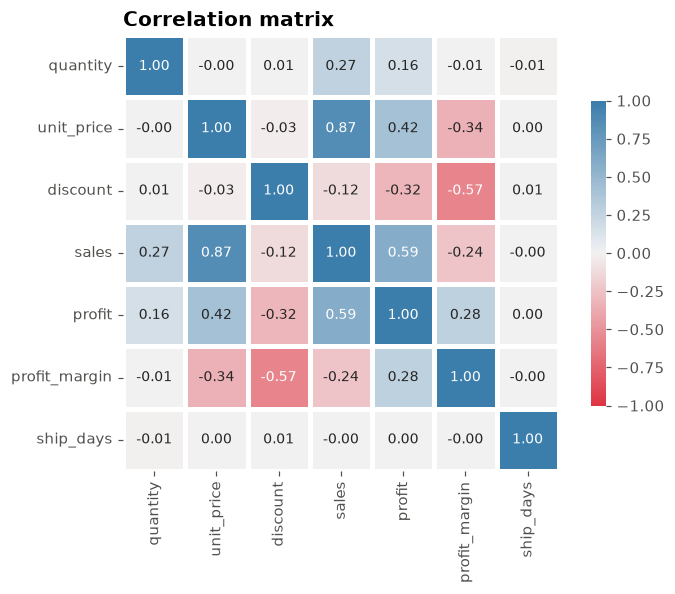

In [14]:
num = df[["quantity", "unit_price", "discount", "sales", "profit", "profit_margin", "ship_days"]]
corr = num.corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
cmap = sns.diverging_palette(10, 240, s=80, l=50, as_cmap=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, center=0, vmin=-1, vmax=1, square=True,
            linewidths=2, linecolor="white", cbar_kws={"shrink": .7}, ax=ax, annot_kws={"size": 9})
ax.set_title("Correlation matrix"); ax.grid(False)
save("07_correlation_heatmap.png")

**Observation:** `discount` is clearly negatively correlated with `profit_margin` (r = -0.57) - the single clearest lever in the data. `sales` correlates with `unit_price` and `quantity` as expected. `ship_days` has no relationship with profit, so faster shipping is not eating margin.

## 10. Key findings and recommendations

| # | Finding | Evidence | Recommended action |
|---|---------|----------|--------------------|
| 1 | Business is growing | 2025 sales +18.5% YoY, every month positive | Plan capacity for continued growth; Q4 peak is 2x February |
| 2 | Discounts above 20% destroy profit | margin -4% at 30%, -17% at 50%; ANOVA p << 0.001; r = -0.57 | Cap standard discounts at 20%; require approval above that |
| 3 | Furniture drags margin | Bookcases lose money in every region; Tables 19% of revenue at ~1% margin | Renegotiate supplier cost or reprice; consider dropping Bookcases |
| 4 | Technology is the profit engine | Machines + Phones = 52% of sales, 64% of profit | Prioritise stock and marketing here |
| 5 | Region differences are small | margin range 8.1%-9.2% | Focus on product mix and discounting, not geography |
| 6 | No customer concentration risk | top 20% of customers = ~41% of revenue | Healthy; Home Office segment has best margin for upsell |
| 7 | Shipping meets SLA | avg days within promised window for every mode | No action needed |

**Limitations:** the dataset is synthetic (modelled on Superstore-style retail data), so absolute numbers are illustrative; the *method* - cleaning, SQL, EDA, statistics, dashboard - is the deliverable.